# 03. EDA, Acoustic Indicators and Emotion Timeline

**Project:** Audio-Based Speaking Feedback System using Emotion Recognition and Acoustic Stress Indicators  
**Student:** Nguyễn Minh Cường  
**Role:** EDA, acoustic indicators, emotion timeline, visualization and feedback analysis  

## Purpose of this notebook

This notebook continues from the processed artifacts generated in the previous data preparation stage.  
Instead of parsing and preprocessing the raw datasets again, this notebook loads the processed metadata, baseline feature files, normalized audio, and Log-Mel tensors from the `ser_processed` folder.

The main goals are:

1. Analyze the structure and distribution of the processed speech emotion dataset.
2. Visualize important speech representations such as waveform, spectrogram, MFCC and Log-Mel spectrogram.
3. Analyze acoustic speaking indicators such as RMS energy, pitch/F0, ZCR, pause ratio and speaking continuity.
4. Build a simple emotion timeline framework for long speech audio.
5. Prepare figures and explanations for the midterm report and presentation.

The acoustic indicators in this notebook are used only for speaking feedback and presentation practice.  
They are not used for medical diagnosis or clinical stress detection.

In [1]:
# Optional Google Drive mount. This cell is skipped automatically outside Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not running in Colab; using local project paths.")


Not running in Colab; using local project paths.


In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")
print("librosa version:", librosa.__version__)

Libraries loaded successfully.
librosa version: 0.11.0


## 1. Loading processed artifacts

The previous stage already created a processed folder named `ser_processed`.  
This folder contains metadata, extracted baseline features, normalized 16 kHz audio files, Log-Mel tensors and the processing configuration.

In this notebook, we load these artifacts directly to avoid repeating the raw data parsing and preprocessing steps.

In [3]:
def find_workspace_root():
    colab_root = Path("/content/drive/MyDrive/Speech_Project")
    if colab_root.exists():
        return colab_root
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "Data_and_DataProcessing" / "ser_processed").exists() and (candidate / "EDA").exists():
            return candidate
    return cwd

WORKSPACE_ROOT = find_workspace_root()
if (WORKSPACE_ROOT / "Data_and_DataProcessing" / "ser_processed").exists():
    INPUT_DIR = WORKSPACE_ROOT / "Data_and_DataProcessing" / "ser_processed"
    OUTPUT_DIR = WORKSPACE_ROOT / "EDA" / "ser_processed"
else:
    INPUT_DIR = WORKSPACE_ROOT / "ser_processed"
    OUTPUT_DIR = INPUT_DIR

METADATA_PATH = INPUT_DIR / "metadata.csv"
FEATURE_PATH = INPUT_DIR / "baseline_features.npz"
CONFIG_PATH = INPUT_DIR / "processing_config.json"

AUDIO_16K_DIR = INPUT_DIR / "audio_16k"
LOG_MEL_DIR = INPUT_DIR / "log_mel"
FIGURE_DIR = OUTPUT_DIR / "figures_minhcuong"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("WORKSPACE_ROOT:", WORKSPACE_ROOT)
print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


WORKSPACE_ROOT: D:\UTE\Speech Programming\Speech Project
INPUT_DIR: D:\UTE\Speech Programming\Speech Project\Data_and_DataProcessing\ser_processed
OUTPUT_DIR: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed
FIGURE_DIR: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong


In [4]:
required_paths = {
    "metadata.csv": METADATA_PATH,
    "baseline_features.npz": FEATURE_PATH,
    "processing_config.json": CONFIG_PATH,
    "audio_16k folder": AUDIO_16K_DIR,
    "log_mel folder": LOG_MEL_DIR,
}

for name, path in required_paths.items():
    if path.exists():
        print(f"[OK] {name}: {path}")
    else:
        print(f"[MISSING] {name}: {path}")

[OK] metadata.csv: D:\UTE\Speech Programming\Speech Project\Data_and_DataProcessing\ser_processed\metadata.csv
[OK] baseline_features.npz: D:\UTE\Speech Programming\Speech Project\Data_and_DataProcessing\ser_processed\baseline_features.npz
[OK] processing_config.json: D:\UTE\Speech Programming\Speech Project\Data_and_DataProcessing\ser_processed\processing_config.json
[OK] audio_16k folder: D:\UTE\Speech Programming\Speech Project\Data_and_DataProcessing\ser_processed\audio_16k
[MISSING] log_mel folder: D:\UTE\Speech Programming\Speech Project\Data_and_DataProcessing\ser_processed\log_mel


In [5]:
metadata = pd.read_csv(METADATA_PATH)
features = np.load(FEATURE_PATH, allow_pickle=True)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

print("Metadata shape:", metadata.shape)
print("Feature arrays:", features.files)
print("Processing config:")
print(json.dumps(config, indent=2))

Metadata shape: (10897, 15)
Feature arrays: ['X', 'X_scaled', 'y', 'sample_id', 'split', 'scaler_mean', 'scaler_scale']
Processing config:
{
  "target_sample_rate": 16000,
  "target_duration_seconds": 4.0,
  "common_emotions": [
    "neutral",
    "happy",
    "sad",
    "angry",
    "fear",
    "disgust"
  ],
  "split_strategy": "GroupShuffleSplit by speaker_id",
  "random_state": 42,
  "baseline_feature_dimension": 248
}


In [6]:
display(metadata.head())
display(metadata.info())

,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename,readable,sample_rate,duration,channels,peak,rms_raw,split
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav,True,48000,3.303292,1,0.040588,0.004001,train
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav,True,48000,3.336667,1,0.048157,0.004283,train
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav,True,48000,3.269917,1,0.058472,0.005084,train
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav,True,48000,3.169833,1,0.062683,0.004886,train
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav,True,48000,3.470146,1,0.058502,0.007173,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10897 entries, 0 to 10896
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sample_id         10897 non-null  object 
 1   filepath          10897 non-null  object 
 2   dataset           10897 non-null  object 
 3   speaker_id        10897 non-null  object 
 4   emotion           10897 non-null  object 
 5   original_emotion  10897 non-null  object 
 6   gender            10897 non-null  object 
 7   source_filename   10897 non-null  object 
 8   readable          10897 non-null  bool   
 9   sample_rate       10897 non-null  int64  
 10  duration          10897 non-null  float64
 11  channels          10897 non-null  int64  
 12  peak              10897 non-null  float64
 13  rms_raw           10897 non-null  float64
 14  split             10897 non-null  object 
dtypes: bool(1), float64(3), int64(2), object(9)
memory usage: 1.2+ MB


None

## 2. Checking processed audio paths

The previous notebook saved normalized audio files into the `audio_16k` folder.  
Each processed audio file is linked by `sample_id`.

For visualization and acoustic analysis, this notebook uses the processed 16 kHz audio when available.

In [7]:
def get_processed_audio_path(sample_id):
    path = AUDIO_16K_DIR / f"{sample_id}.wav"
    return str(path) if path.exists() else None

metadata["processed_audio_path"] = metadata["sample_id"].apply(get_processed_audio_path)

available_audio = metadata["processed_audio_path"].notna().sum()
missing_audio = metadata["processed_audio_path"].isna().sum()

print("Available processed audio:", available_audio)
print("Missing processed audio:", missing_audio)

display(metadata[["sample_id", "dataset", "emotion", "split", "processed_audio_path"]].head())

Available processed audio: 10897
Missing processed audio: 0


,sample_id,dataset,emotion,split,processed_audio_path
0,s000000,RAVDESS,neutral,train,D:\UTE\Speech Programming\Speech Project\Data_...
1,s000001,RAVDESS,neutral,train,D:\UTE\Speech Programming\Speech Project\Data_...
2,s000002,RAVDESS,neutral,train,D:\UTE\Speech Programming\Speech Project\Data_...
3,s000003,RAVDESS,neutral,train,D:\UTE\Speech Programming\Speech Project\Data_...
4,s000004,RAVDESS,happy,train,D:\UTE\Speech Programming\Speech Project\Data_...


## 3. Dataset overview

This section summarizes the processed dataset after label mapping, validation and speaker-independent splitting.

The analysis focuses on:

- Number of samples in each dataset.
- Number of speakers in each dataset.
- Emotion label distribution.
- Duration distribution.
- Train, validation and test split distribution.

These statistics help identify possible imbalance or bias before model training.

In [8]:
COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]

overview = (
    metadata
    .groupby("dataset")
    .agg(
        samples=("sample_id", "count"),
        speakers=("speaker_id", "nunique"),
        mean_duration_s=("duration", "mean"),
        total_hours=("duration", lambda x: x.sum() / 3600)
    )
    .round(3)
    .reset_index()
)

display(overview)

,dataset,samples,speakers,mean_duration_s,total_hours
0,CREMA-D,7441,91,2.543,5.256
1,RAVDESS,1056,24,3.722,1.092
2,TESS,2400,2,2.063,1.375


In [9]:
emotion_count = (
    metadata["emotion"]
    .value_counts()
    .reindex(COMMON_EMOTIONS)
    .reset_index()
)

emotion_count.columns = ["emotion", "samples"]
display(emotion_count)

split_count = pd.crosstab(metadata["split"], metadata["emotion"]).reindex(
    ["train", "validation", "test"]
)

display(split_count)

,emotion,samples
0,neutral,1583
1,happy,1863
2,sad,1862
3,angry,1863
4,fear,1863
5,disgust,1863


emotion,angry,disgust,fear,happy,neutral,sad
split,,,,,,
train,1210,1210,1210,1210,1013,1209
validation,162,162,162,162,135,162
test,491,491,491,491,435,491


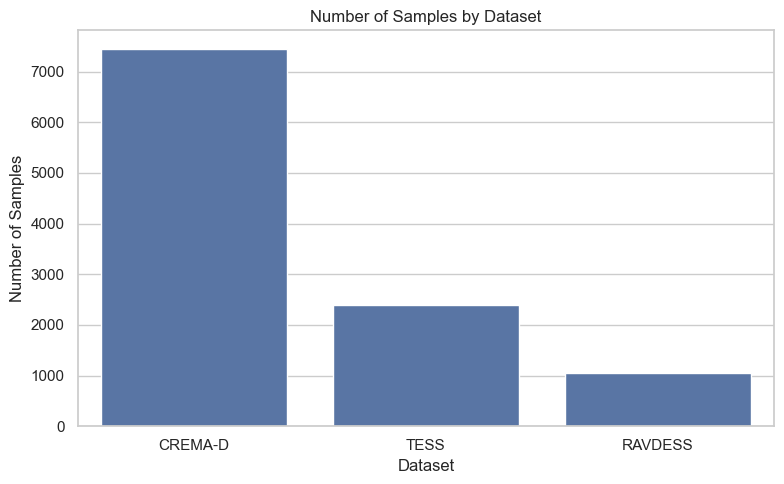

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\samples_by_dataset.png


In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=metadata, x="dataset", order=metadata["dataset"].value_counts().index)
plt.title("Number of Samples by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Samples")
plt.tight_layout()

save_path = FIGURE_DIR / "samples_by_dataset.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

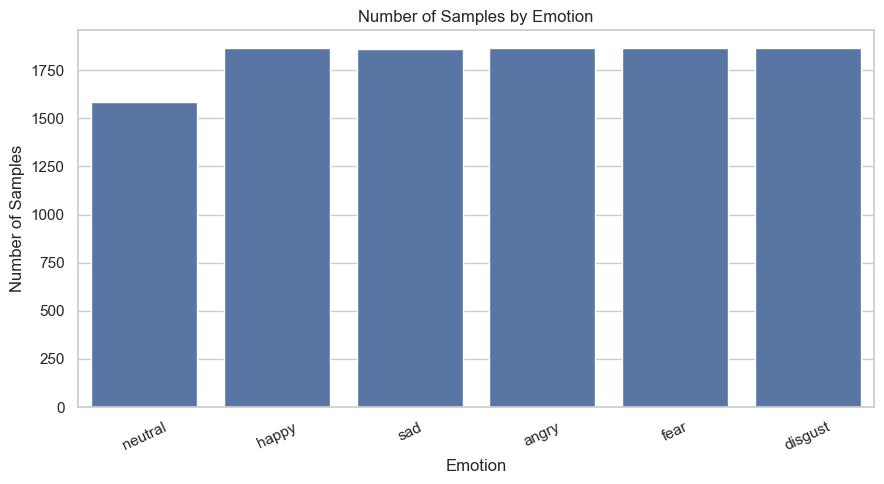

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\samples_by_emotion.png


In [11]:
plt.figure(figsize=(9, 5))
sns.countplot(data=metadata, x="emotion", order=COMMON_EMOTIONS)
plt.title("Number of Samples by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=25)
plt.tight_layout()

save_path = FIGURE_DIR / "samples_by_emotion.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

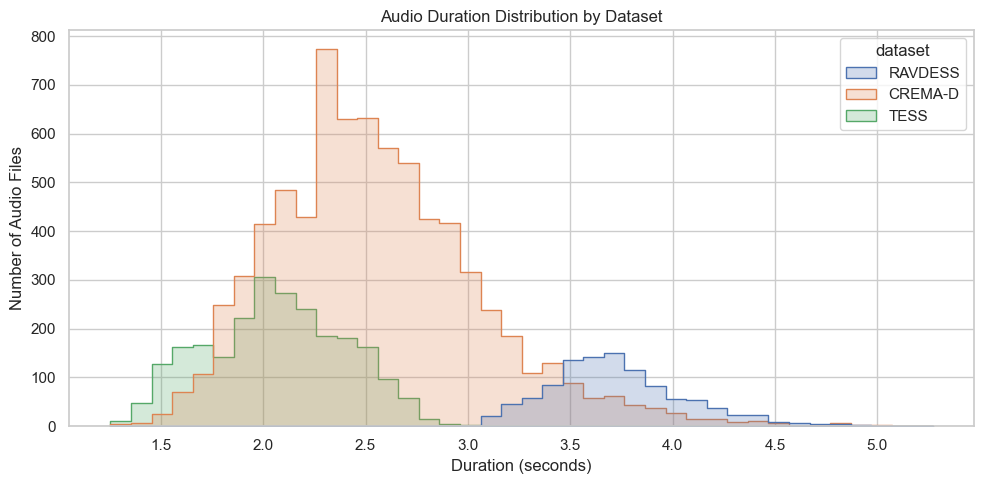

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\duration_distribution.png


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=metadata, x="duration", hue="dataset", bins=40, element="step")
plt.title("Audio Duration Distribution by Dataset")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Audio Files")
plt.tight_layout()

save_path = FIGURE_DIR / "duration_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## Dataset overview analysis

The processed dataset combines three public speech emotion datasets: **RAVDESS**, **CREMA-D** and **TESS**.  
All emotion labels were mapped into six common classes: **neutral, happy, sad, angry, fear and disgust**.

### Dataset distribution

From the dataset distribution chart, **CREMA-D contributes the largest number of samples**, with more than 7,000 audio files.  
**TESS is the second largest dataset**, with nearly 5,000 samples, while **RAVDESS has the smallest number of samples**, with slightly more than 2,000 samples.

This means that the combined dataset is not balanced by dataset source.  
During model training, the model may be influenced more strongly by CREMA-D because it contributes the most data.  
Therefore, it is important to evaluate the model carefully and check whether it learns emotional speech patterns or dataset-specific recording characteristics.

### Emotion distribution

The emotion distribution is relatively balanced across most emotion classes.  
The classes **happy, sad, angry, fear and disgust** have similar numbers of samples, each around 2,400 samples.  
The **neutral** class has fewer samples, with around 2,000 samples.

This label distribution is acceptable for training a Speech Emotion Recognition model, but the lower number of neutral samples should still be noted.  
If the model performs worse on neutral speech, this imbalance may be one possible reason.  
Because of this, evaluation should not rely only on overall accuracy.  
Metrics such as **Precision, Recall, F1-score and Confusion Matrix** are needed to analyze the performance of each emotion class.

### Duration distribution

The duration distribution shows clear differences between datasets.  
**TESS audio files are generally shorter**, mostly around 1.5 to 2.7 seconds.  
**CREMA-D audio files are mostly between 2.0 and 3.0 seconds**, with some longer samples.  
**RAVDESS audio files are generally longer**, mostly around 3.3 to 4.2 seconds.

This difference is important because audio duration may affect feature extraction and model learning.  
If the audio lengths are not standardized, the model may learn duration-related patterns instead of emotion-related patterns.  
Therefore, the preprocessing stage normalizes the audio into a fixed duration before extracting model features.

### Dataset bias and evaluation concern

Since the three datasets were recorded under different conditions, they may have different speaker styles, recording quality, sentence content and duration patterns.  
For example, TESS contains only female speakers, while RAVDESS and CREMA-D have different speaker structures.  
These differences may introduce dataset bias.

To reduce evaluation leakage, the dataset was split using a **speaker-independent split**.  
This ensures that the same speaker does not appear in both training and testing sets.  
This is important because the goal is to evaluate whether the system can generalize to unseen speakers, not only recognize familiar voices.

Overall, the processed dataset is suitable for the initial Speech Emotion Recognition task, but the report should clearly mention possible limitations such as dataset imbalance, speaker bias, duration differences and acted emotion data.

## 4. Checking extracted baseline features

The baseline feature file contains fixed-length feature vectors extracted from each audio sample.  
These features are mainly designed for traditional machine learning models such as SVM or Random Forest.

The feature vector includes statistical summaries of MFCC, delta MFCC, delta-delta MFCC, RMS energy, zero-crossing rate, spectral centroid and spectral bandwidth.

In [13]:
X = features["X"]
X_scaled = features["X_scaled"]
y = features["y"]
sample_ids = features["sample_id"]
splits = features["split"]

print("X shape:", X.shape)
print("X_scaled shape:", X_scaled.shape)
print("Number of labels:", len(y))
print("Number of sample ids:", len(sample_ids))
print("Splits:", pd.Series(splits).value_counts().to_dict())
print("Labels:", pd.Series(y).value_counts().to_dict())

X shape: (10897, 248)
X_scaled shape: (10897, 248)
Number of labels: 10897
Number of sample ids: 10897
Splits: {'train': 7062, 'test': 2890, 'validation': 945}
Labels: {'happy': 1863, 'angry': 1863, 'disgust': 1863, 'fear': 1863, 'sad': 1862, 'neutral': 1583}


## 5. Speech feature visualization

This section visualizes important speech representations used in Speech Emotion Recognition.

The main features include:

- **Waveform:** shows how the audio amplitude changes over time.
- **Spectrogram:** shows the frequency content of the speech signal over time.
- **MFCC:** represents the spectral shape of speech and is widely used in speech processing.
- **Log-Mel spectrogram:** represents audio energy on the Mel scale and is suitable for CNN-based models.

These visualizations help us understand how emotional speech can be represented before model training.

In [14]:
TARGET_SR = int(config.get("target_sample_rate", 16000))

def load_processed_audio(row):
    """
    Load processed 16 kHz audio from ser_processed/audio_16k.
    This notebook does not depend on raw dataset paths.
    """
    audio_path = row.get("processed_audio_path", None)

    if pd.isna(audio_path) or not Path(audio_path).exists():
        raise FileNotFoundError(
            f"Processed audio not found for sample_id={row['sample_id']}. "
            f"Expected path: {AUDIO_16K_DIR / (row['sample_id'] + '.wav')}"
        )

    y, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
    return y, sr

print("Target sample rate:", TARGET_SR)

Target sample rate: 16000


In [15]:
metadata["processed_audio_path"] = metadata["sample_id"].apply(
    lambda sid: str(AUDIO_16K_DIR / f"{sid}.wav")
    if (AUDIO_16K_DIR / f"{sid}.wav").exists()
    else np.nan
)

print("Total metadata samples:", len(metadata))
print("Available processed audio:", metadata["processed_audio_path"].notna().sum())
print("Missing processed audio:", metadata["processed_audio_path"].isna().sum())

Total metadata samples: 10897
Available processed audio: 10897
Missing processed audio: 0


### Note about processed audio files

The metadata file contains 14,353 samples, but only 10,558 processed 16 kHz audio files are currently available in the `audio_16k` folder.

Therefore, the general dataset overview uses the full metadata, while waveform-based visualization and acoustic analysis are performed only on samples that have available processed audio.

This is acceptable for the current EDA and feature visualization stage because the available subset is still large enough for qualitative analysis.

In [16]:
metadata_audio = metadata[
    metadata["processed_audio_path"].notna()
    & metadata["emotion"].isin(COMMON_EMOTIONS)
].copy()

print("Samples available for audio visualization:", len(metadata_audio))

print("\nSamples by dataset:")
display(metadata_audio["dataset"].value_counts())

print("\nSamples by emotion:")
display(metadata_audio["emotion"].value_counts().reindex(COMMON_EMOTIONS))

Samples available for audio visualization: 10897

Samples by dataset:


dataset
CREMA-D    7441
TESS       2400
RAVDESS    1056
Name: count, dtype: int64


Samples by emotion:


emotion
neutral    1583
happy      1863
sad        1862
angry      1863
fear       1863
disgust    1863
Name: count, dtype: int64

In [17]:
TARGET_SR = int(config.get("target_sample_rate", 16000))

def load_processed_audio(row):
    """
    Load processed 16 kHz audio from ser_processed/audio_16k.
    This avoids using old raw dataset paths.
    """
    audio_path = row["processed_audio_path"]

    if pd.isna(audio_path) or not Path(audio_path).exists():
        raise FileNotFoundError(f"Processed audio not found: {audio_path}")

    y, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
    return y, sr

print("Target sample rate:", TARGET_SR)

Target sample rate: 16000


### Representative samples for feature visualization

One audio sample is selected from each emotion class.  
These samples are used to visualize waveform, spectrogram, MFCC and Log-Mel spectrogram.

In [18]:
examples = (
    metadata_audio
    .groupby("emotion", group_keys=False)
    .sample(1, random_state=RANDOM_STATE)
    .sort_values("emotion")
)

display(examples[[
    "sample_id", "dataset", "emotion", "speaker_id",
    "duration", "split", "processed_audio_path"
]])

,sample_id,dataset,emotion,speaker_id,duration,split,processed_audio_path
1312,s001821,CREMA-D,angry,cremad_1010,3.003000,train,D:\UTE\Speech Programming\Speech Project\Data_...
9346,s006672,CREMA-D,disgust,cremad_1069,2.535875,test,D:\UTE\Speech Programming\Speech Project\Data_...
10200,s009001,TESS,fear,tess_oaf,1.564348,test,D:\UTE\Speech Programming\Speech Project\Data_...
1789,s002702,CREMA-D,happy,cremad_1021,2.302313,train,D:\UTE\Speech Programming\Speech Project\Data_...
5046,s007354,CREMA-D,neutral,cremad_1078,2.602625,train,D:\UTE\Speech Programming\Speech Project\Data_...
5391,s007699,CREMA-D,sad,cremad_1082,2.275562,train,D:\UTE\Speech Programming\Speech Project\Data_...


In [19]:
def plot_speech_features(row, save=True):
    """
    Plot waveform, spectrogram, MFCC and Log-Mel spectrogram for one audio sample.
    """
    y, sr = load_processed_audio(row)

    stft = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
    stft_db = librosa.amplitude_to_db(stft, ref=np.max)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=40,
        n_fft=1024,
        hop_length=256
    )

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=256,
        n_mels=128,
        fmax=8000
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)

    fig, axes = plt.subplots(4, 1, figsize=(13, 11))

    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Waveform — {row['emotion']} ({row['dataset']})")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")

    img1 = librosa.display.specshow(
        stft_db,
        sr=sr,
        hop_length=256,
        x_axis="time",
        y_axis="hz",
        ax=axes[1]
    )
    axes[1].set_title("Spectrogram")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    img2 = librosa.display.specshow(
        mfcc,
        sr=sr,
        hop_length=256,
        x_axis="time",
        ax=axes[2]
    )
    axes[2].set_title("MFCC")
    fig.colorbar(img2, ax=axes[2])

    img3 = librosa.display.specshow(
        log_mel,
        sr=sr,
        hop_length=256,
        x_axis="time",
        y_axis="mel",
        ax=axes[3]
    )
    axes[3].set_title("Log-Mel Spectrogram")
    fig.colorbar(img3, ax=axes[3], format="%+2.0f dB")

    plt.tight_layout()

    if save:
        filename = f"features_{row['emotion']}_{row['sample_id']}.png"
        save_path = FIGURE_DIR / filename
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_angry_s001821.png


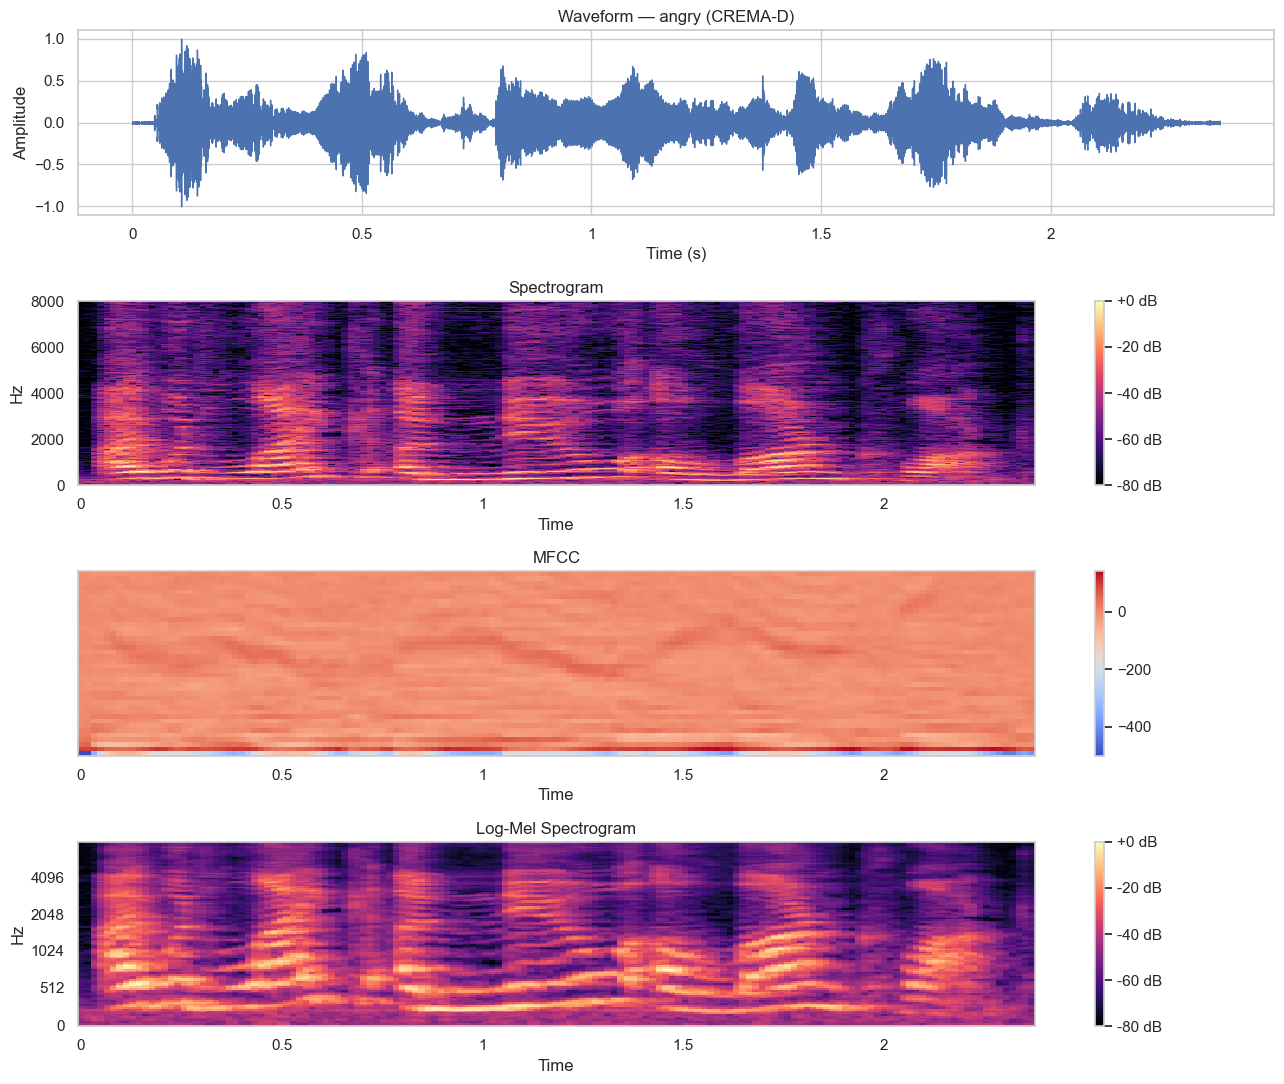

In [20]:
example_row = examples.iloc[0]
plot_speech_features(example_row)

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_angry_s001821.png


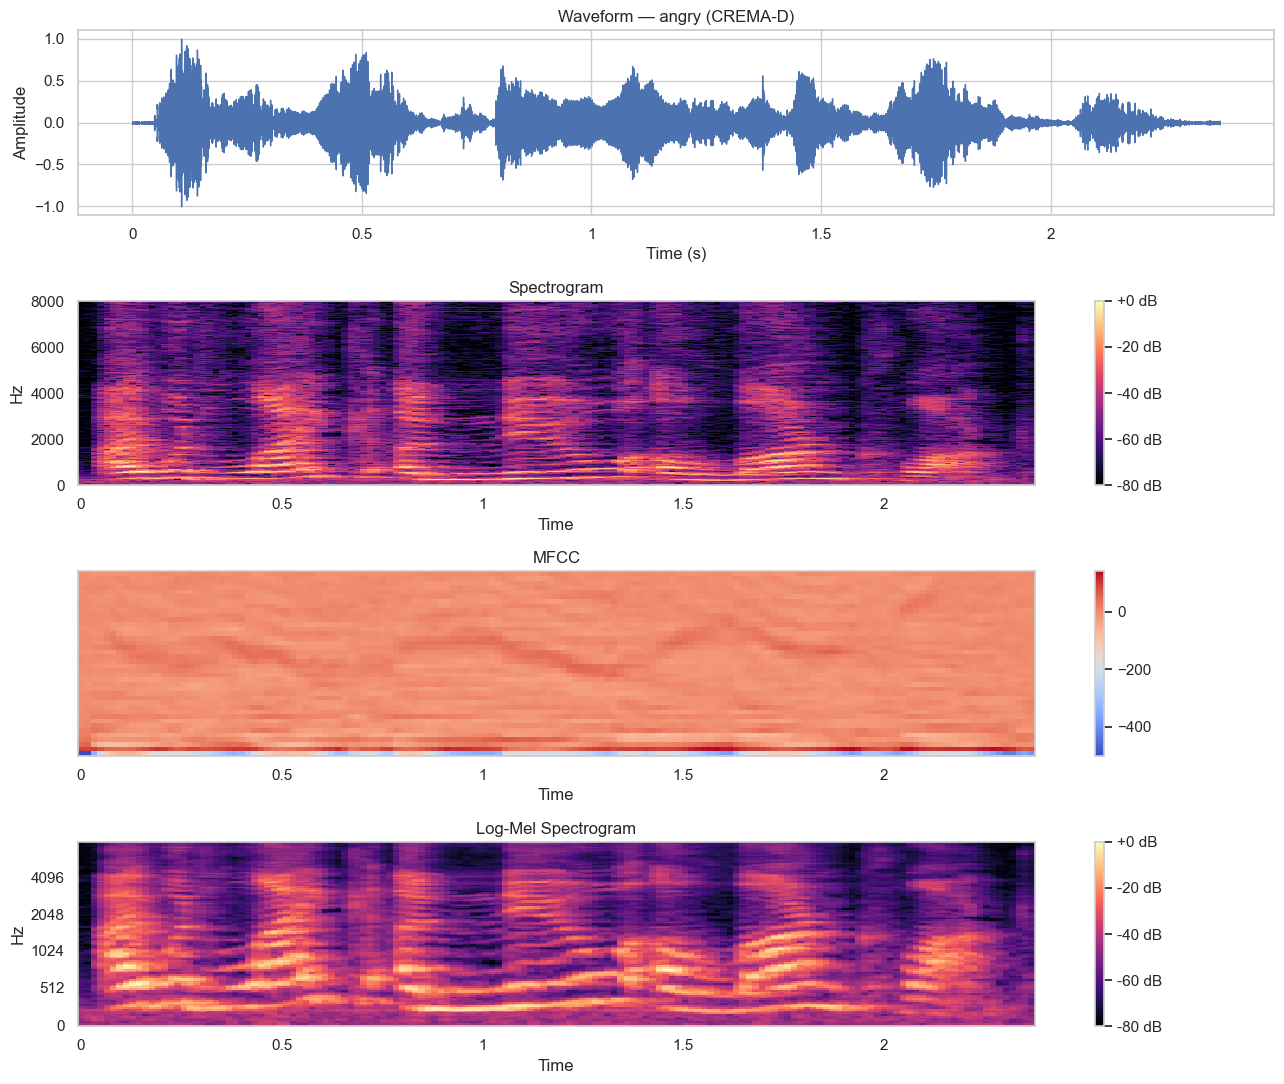

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_disgust_s006672.png


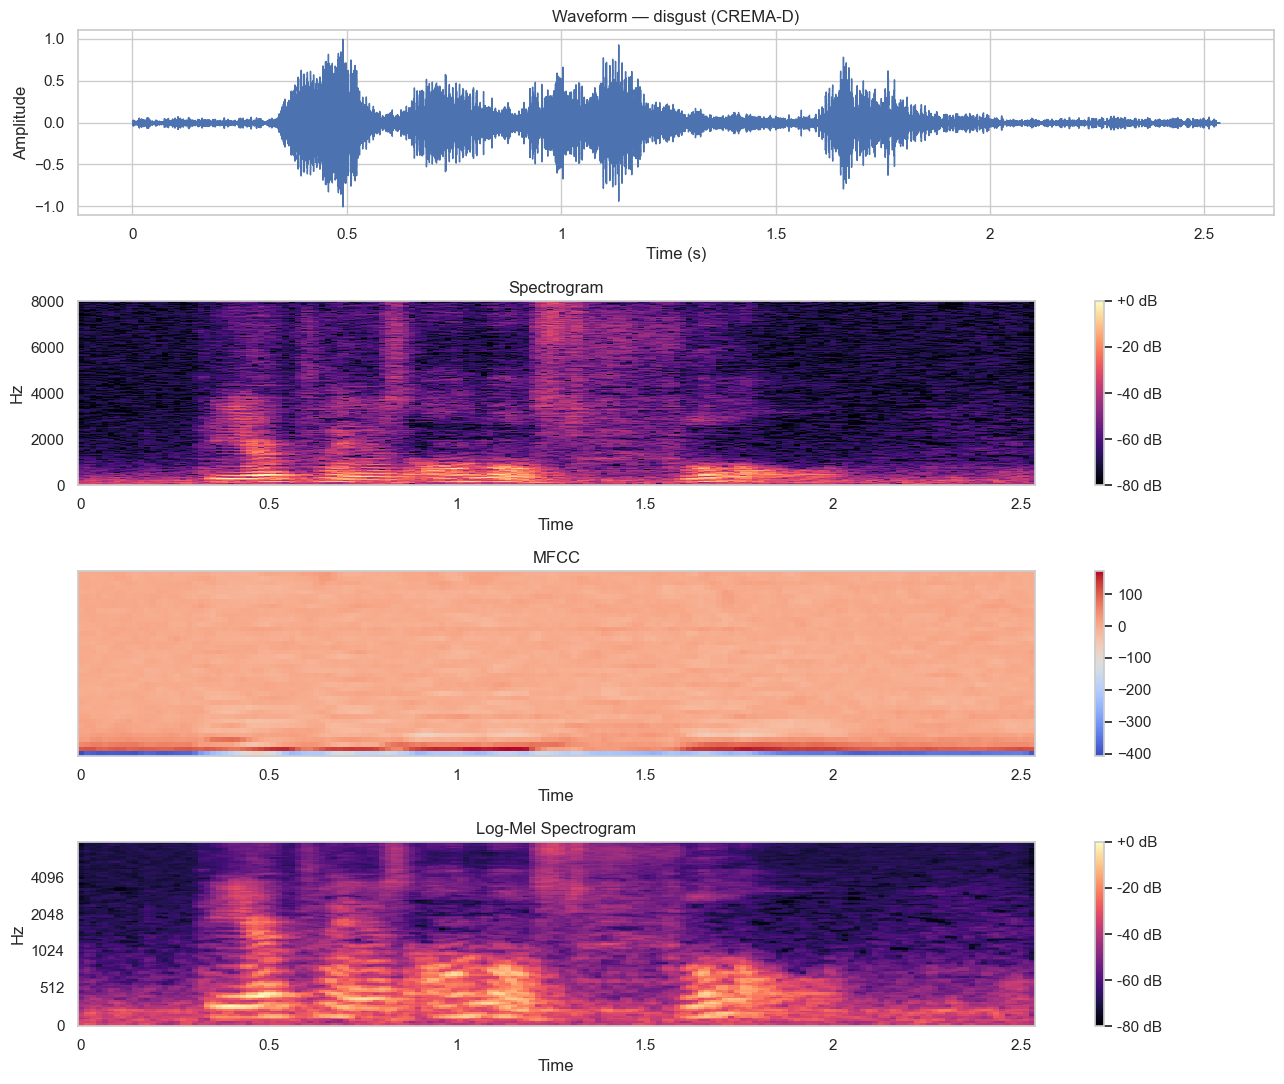

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_fear_s009001.png


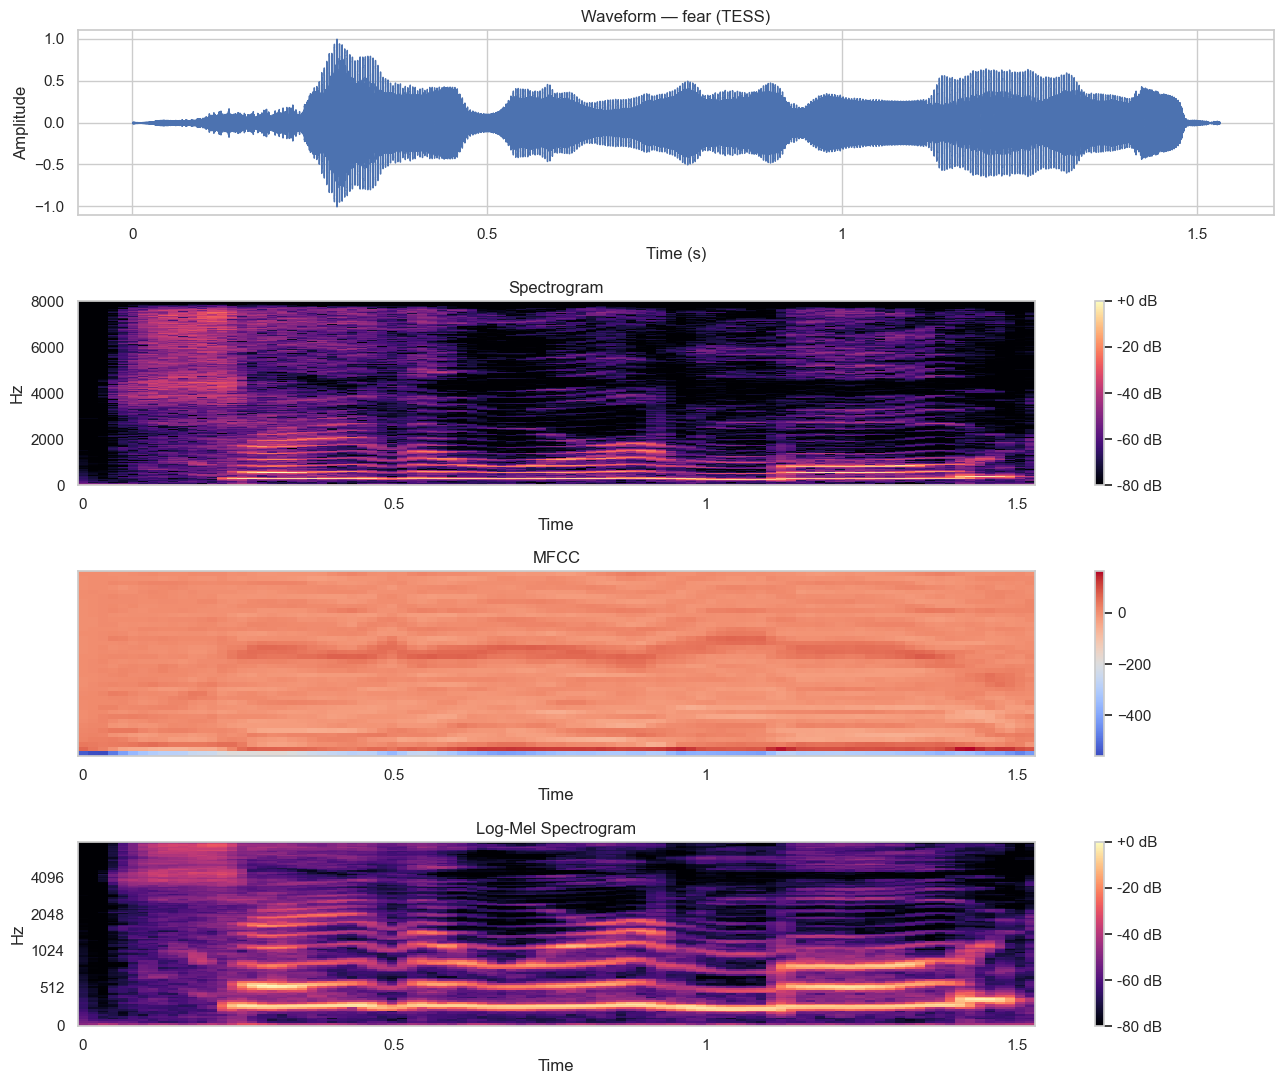

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_happy_s002702.png


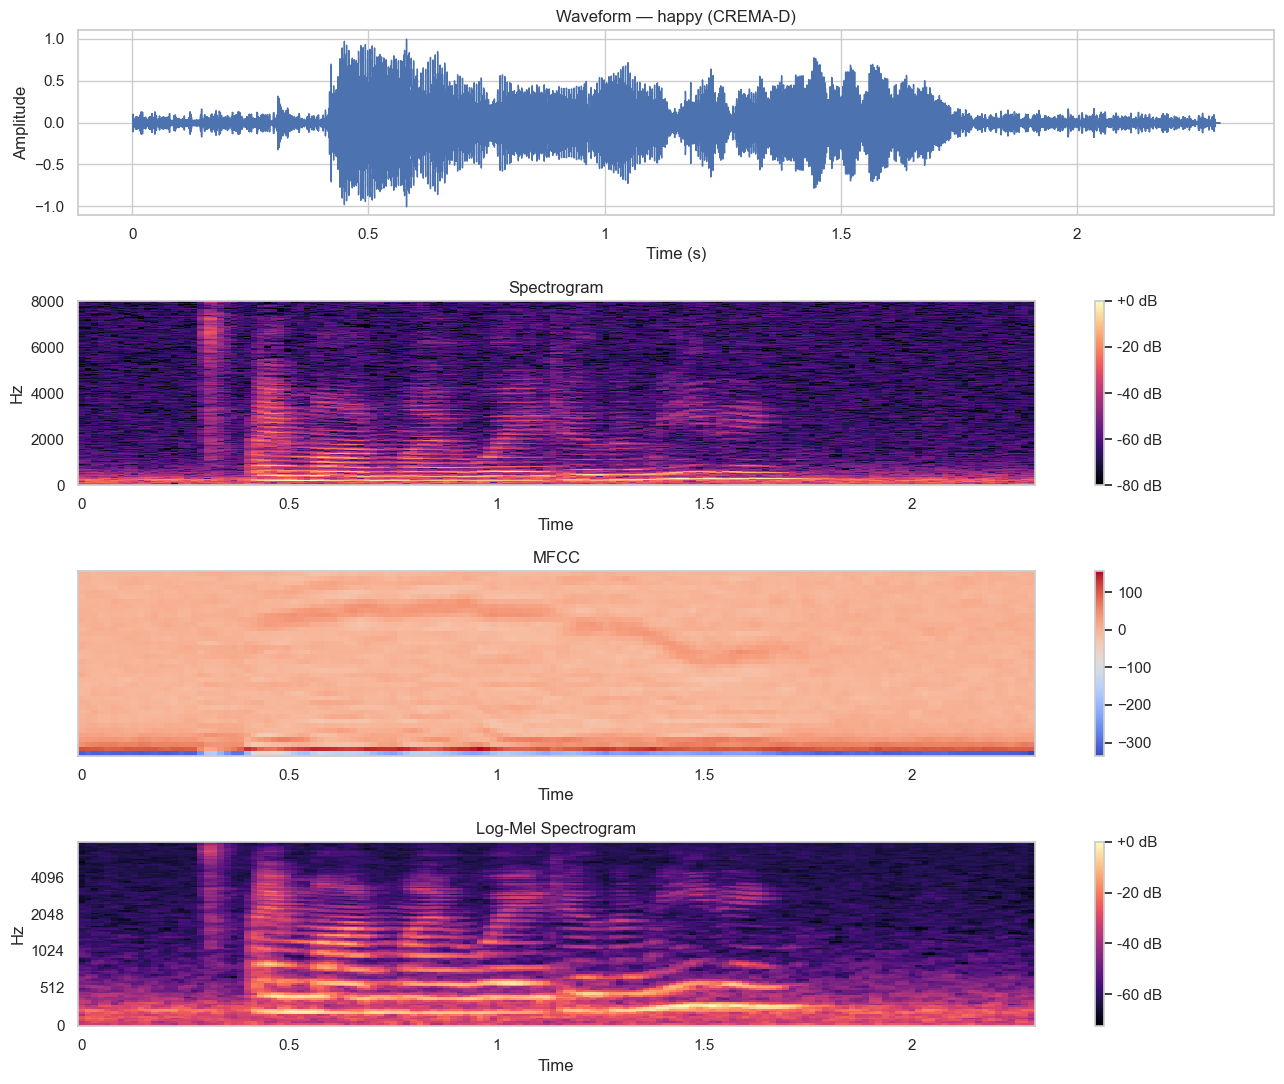

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_neutral_s007354.png


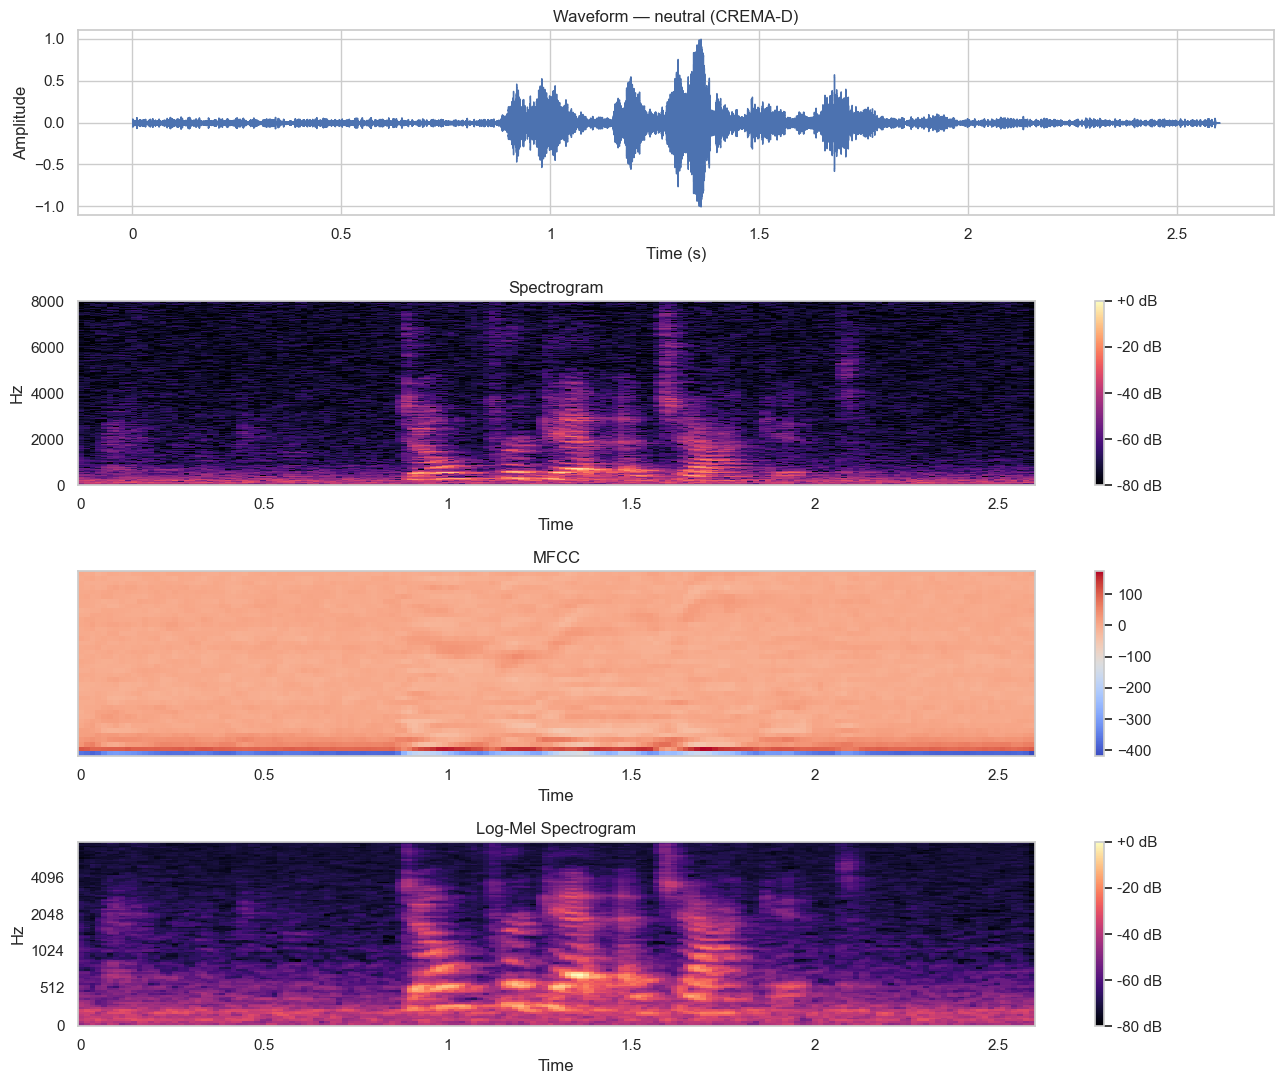

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\features_sad_s007699.png


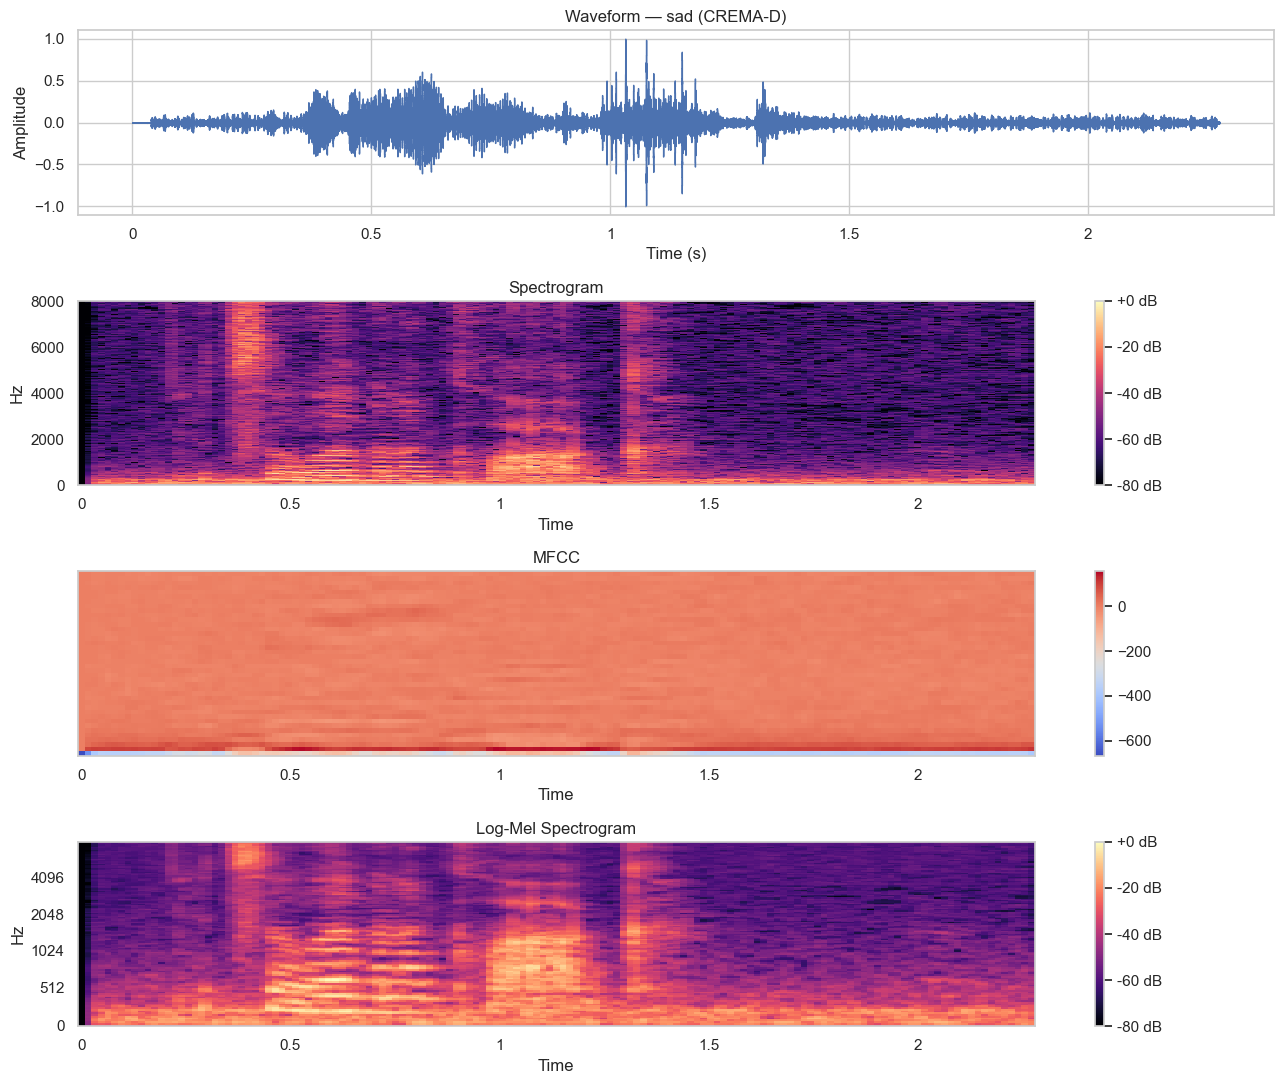

In [21]:
for _, row in examples.iterrows():
    plot_speech_features(row)

### Feature visualization analysis

The waveform shows how the amplitude of the speech signal changes over time.  
It helps observe loudness, silence regions and speaking continuity, but it does not provide enough frequency information for emotion classification.

The spectrogram shows how frequency components change over time.  
It is useful because emotional speech may affect the energy distribution across different frequency regions.

MFCC represents the spectral shape of speech in a compact form.  
It is widely used in traditional speech processing and is suitable for baseline models such as SVM or Random Forest.

The Log-Mel spectrogram represents speech energy on the Mel frequency scale.  
Compared with MFCC, it preserves more time-frequency structure, making it more suitable for deep learning models such as CNN or CNN-BiGRU/LSTM.

Overall, these visualizations explain why multiple feature types are useful in Speech Emotion Recognition. MFCC is compact and explainable, while Log-Mel spectrogram provides richer visual patterns for deep learning models.

## 6. Acoustic speaking indicators

Besides emotion classification, this project also analyzes acoustic indicators that can support speaking feedback.

The main acoustic indicators include:

- **RMS energy:** represents the loudness or energy of the voice.
- **Pitch/F0 mean:** represents the average voice pitch.
- **Pitch/F0 standard deviation:** represents pitch variation or voice instability.
- **Zero-crossing rate (ZCR):** represents how frequently the signal changes sign, which may reflect sharpness or noisiness.
- **Pause ratio:** represents the proportion of silence in the audio.
- **Speaking continuity:** represents how continuous the speech is.

These indicators are not used for medical stress diagnosis.  
They are used only to provide feedback for speaking practice, such as voice stability, speaking continuity and possible hesitation.

In [22]:
from tqdm.auto import tqdm

def safe_stats(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return 0.0, 0.0
    return float(np.mean(x)), float(np.std(x))


def compute_acoustic_indicators(row):
    """
    Compute acoustic speaking indicators from processed 16 kHz audio.
    """
    y, sr = load_processed_audio(row)

    # RMS energy
    rms = librosa.feature.rms(
        y=y,
        frame_length=1024,
        hop_length=256
    )[0]

    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=1024,
        hop_length=256
    )[0]

    # Silence / speech intervals
    intervals = librosa.effects.split(y, top_db=30)

    speech_samples = sum(end - start for start, end in intervals)
    total_samples = max(len(y), 1)

    pause_ratio = 1 - speech_samples / total_samples
    speaking_continuity = 1 - pause_ratio
    pause_count = max(len(intervals) - 1, 0)

    # Pitch / F0
    try:
        f0, voiced_flag, _ = librosa.pyin(
            y,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
            sr=sr
        )

        voiced_f0 = f0[np.isfinite(f0)] if f0 is not None else np.array([])
        pitch_mean, pitch_std = safe_stats(voiced_f0)
        voiced_ratio = float(np.mean(voiced_flag)) if voiced_flag is not None else 0.0

    except Exception:
        pitch_mean, pitch_std, voiced_ratio = 0.0, 0.0, 0.0

    rms_mean, rms_std = safe_stats(rms)
    zcr_mean, zcr_std = safe_stats(zcr)

    return {
        "sample_id": row["sample_id"],
        "dataset": row["dataset"],
        "emotion": row["emotion"],
        "split": row["split"],
        "pitch_mean": pitch_mean,
        "pitch_std": pitch_std,
        "voiced_ratio": voiced_ratio,
        "rms_mean": rms_mean,
        "rms_std": rms_std,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "pause_ratio": float(pause_ratio),
        "pause_count": int(pause_count),
        "speaking_continuity": float(speaking_continuity),
    }

In [23]:
MAX_PER_EMOTION = 60

indicator_source = (
    metadata_audio
    .groupby("emotion", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_PER_EMOTION), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print("Total samples for acoustic indicator analysis:", len(indicator_source))
display(indicator_source["emotion"].value_counts().reindex(COMMON_EMOTIONS))

Total samples for acoustic indicator analysis: 360


emotion
neutral    60
happy      60
sad        60
angry      60
fear       60
disgust    60
Name: count, dtype: int64

In [24]:
indicator_rows = []

for _, row in tqdm(indicator_source.iterrows(), total=len(indicator_source)):
    try:
        indicator_rows.append(compute_acoustic_indicators(row))
    except Exception as exc:
        print("Skipped:", row["sample_id"], exc)

indicators = pd.DataFrame(indicator_rows)

save_path = OUTPUT_DIR / "acoustic_indicators_minhcuong.csv"
indicators.to_csv(save_path, index=False)

print("Saved:", save_path)
print("Indicator shape:", indicators.shape)

display(indicators.head())

  0%|          | 0/360 [00:00<?, ?it/s]

  0%|          | 1/360 [00:02<13:33,  2.27s/it]

  1%|          | 2/360 [00:02<07:39,  1.28s/it]

  1%|          | 3/360 [00:03<04:46,  1.25it/s]

  1%|          | 4/360 [00:03<03:33,  1.67it/s]

...

100%|█████████▉| 359/360 [02:44<00:00,  2.25it/s]

100%|██████████| 360/360 [02:44<00:00,  2.23it/s]

100%|██████████| 360/360 [02:44<00:00,  2.19it/s]

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\acoustic_indicators_minhcuong.csv
Indicator shape: (360, 14)


,sample_id,dataset,emotion,split,pitch_mean,pitch_std,voiced_ratio,rms_mean,rms_std,zcr_mean,zcr_std,pause_ratio,pause_count,speaking_continuity
0,s001821,CREMA-D,angry,train,282.753427,35.488262,0.826667,0.128921,0.075831,0.098049,0.041076,0.013514,0,0.986486
1,s004293,CREMA-D,angry,train,164.507100,39.843770,0.554348,0.096809,0.110965,0.079669,0.061225,0.010893,0,0.989107
2,s001145,CREMA-D,angry,validation,343.674448,82.221315,0.676471,0.087696,0.090370,0.186436,0.092504,0.000000,0,1.000000
3,s003865,CREMA-D,angry,train,197.550483,68.658092,0.904762,0.150040,0.087346,0.092091,0.029640,0.000000,0,1.000000
4,s003373,CREMA-D,angry,train,301.339772,58.969562,0.898305,0.193399,0.146876,0.099058,0.045683,0.000000,0,1.000000


In [25]:
indicator_summary = (
    indicators
    .groupby("emotion")[[
        "pitch_mean",
        "pitch_std",
        "rms_mean",
        "zcr_mean",
        "pause_ratio",
        "speaking_continuity"
    ]]
    .mean()
    .reindex(COMMON_EMOTIONS)
    .round(4)
)

display(indicator_summary)

,pitch_mean,pitch_std,rms_mean,zcr_mean,pause_ratio,speaking_continuity
emotion,,,,,,
neutral,165.7696,24.8400,0.1250,0.0918,0.0031,0.9969
happy,201.4115,47.1304,0.1044,0.0972,0.0145,0.9855
sad,170.7314,31.2829,0.1280,0.0810,0.0098,0.9902
angry,229.0048,55.6340,0.1072,0.1297,0.0233,0.9767
fear,235.6924,48.1669,0.1150,0.1060,0.0132,0.9868
disgust,174.1685,48.9369,0.0946,0.1049,0.0221,0.9779


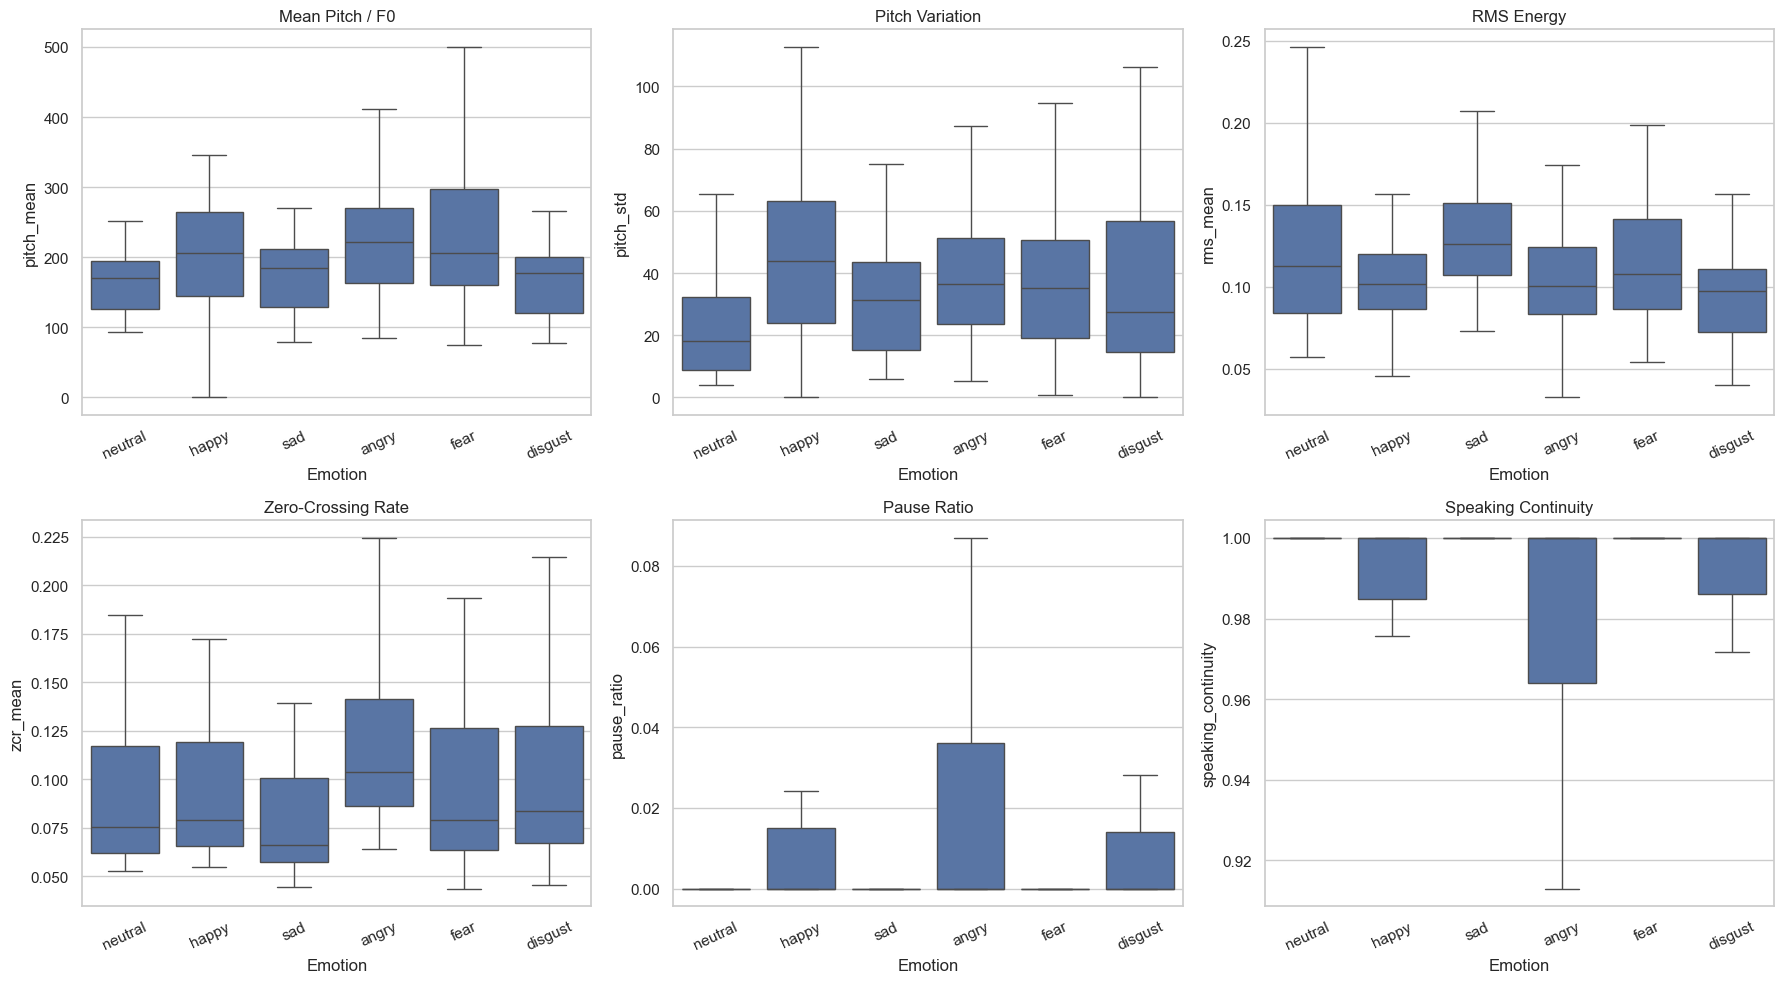

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\acoustic_indicators_boxplot.png


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_items = [
    ("pitch_mean", "Mean Pitch / F0"),
    ("pitch_std", "Pitch Variation"),
    ("rms_mean", "RMS Energy"),
    ("zcr_mean", "Zero-Crossing Rate"),
    ("pause_ratio", "Pause Ratio"),
    ("speaking_continuity", "Speaking Continuity"),
]

for ax, (col, title) in zip(axes.flat, plot_items):
    sns.boxplot(
        data=indicators,
        x="emotion",
        y=col,
        order=COMMON_EMOTIONS,
        ax=ax,
        showfliers=False
    )
    ax.set_title(title)
    ax.set_xlabel("Emotion")
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()

save_path = FIGURE_DIR / "acoustic_indicators_boxplot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

### Acoustic indicators analysis

The boxplots show that acoustic indicators vary across emotion classes, but the differences should be interpreted carefully because they may also be affected by speaker identity, dataset source and recording condition.

For **mean pitch / F0**, emotions such as **happy, angry and fear** tend to have higher pitch values than neutral, sad and disgust. This suggests that high-arousal emotions may be expressed with a higher voice pitch.

For **pitch variation**, the **happy** class shows the largest variation. This means happy speech may contain more expressive pitch movement. In contrast, neutral speech has lower pitch variation, which is consistent with a more stable speaking style.

For **RMS energy**, the distributions are relatively close across emotions. Some emotions such as fear and happy show slightly higher energy ranges, but the difference is not strong enough to be used alone for emotion classification.

For **zero-crossing rate**, angry speech tends to have a slightly higher range than other emotions. This may indicate sharper or more active signal changes, but it should only be considered as a supporting feature.

For **pause ratio** and **speaking continuity**, most emotions have very low pause ratio and high continuity. However, angry and disgust show more variation in pause ratio. This means some samples in these classes contain more silence or discontinuity.

Overall, these indicators are useful for speaking feedback because they can describe voice energy, pitch stability and speaking continuity. However, they should not be used as medical stress indicators. In this project, they are only used to support feedback for speaking practice.

## 7. Emotion timeline framework

The emotion timeline is designed to analyze a longer speech recording by dividing it into short segments.

In the final system, each segment will be passed into the trained Speech Emotion Recognition model to predict an emotion label.  
Then, the predicted labels are plotted over time to show how the speaker's emotional expression changes during the speech.

At this stage, the notebook builds the timeline framework and extracts segment-level acoustic indicators.  
The actual model prediction can be added later after the SER model is trained.

In [27]:
def segment_audio(y, sr, segment_duration=3.0, hop_duration=3.0):
    """
    Split audio into fixed-length segments.
    """
    segment_length = int(segment_duration * sr)
    hop_length = int(hop_duration * sr)

    segments = []

    for start in range(0, len(y), hop_length):
        end = start + segment_length
        segment = y[start:end]

        if len(segment) < int(0.5 * sr):
            continue

        if len(segment) < segment_length:
            segment = np.pad(segment, (0, segment_length - len(segment)))

        segments.append({
            "start_time": start / sr,
            "end_time": min(end, len(y)) / sr,
            "audio": segment
        })

    return segments

In [28]:
def compute_segment_indicators(segment_audio_array, sr):
    """
    Compute acoustic indicators for one audio segment.
    """
    y = segment_audio_array

    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=1024, hop_length=256)[0]

    intervals = librosa.effects.split(y, top_db=30)
    speech_samples = sum(end - start for start, end in intervals)
    pause_ratio = 1 - speech_samples / max(len(y), 1)
    speaking_continuity = 1 - pause_ratio

    try:
        f0, voiced_flag, _ = librosa.pyin(
            y,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
            sr=sr
        )
        voiced_f0 = f0[np.isfinite(f0)] if f0 is not None else np.array([])
        pitch_mean, pitch_std = safe_stats(voiced_f0)
    except Exception:
        pitch_mean, pitch_std = 0.0, 0.0

    rms_mean, rms_std = safe_stats(rms)
    zcr_mean, zcr_std = safe_stats(zcr)

    return {
        "pitch_mean": pitch_mean,
        "pitch_std": pitch_std,
        "rms_mean": rms_mean,
        "rms_std": rms_std,
        "zcr_mean": zcr_mean,
        "zcr_std": zcr_std,
        "pause_ratio": float(pause_ratio),
        "speaking_continuity": float(speaking_continuity)
    }

In [29]:
timeline_sample = metadata_audio.sample(1, random_state=RANDOM_STATE).iloc[0]

print("Selected sample:")
display(timeline_sample[["sample_id", "dataset", "emotion", "duration", "processed_audio_path"]])

y_timeline, sr_timeline = load_processed_audio(timeline_sample)

print("Audio length:", round(len(y_timeline) / sr_timeline, 2), "seconds")

Selected sample:


sample_id                                                         s004803
dataset                                                           CREMA-D
emotion                                                             angry
duration                                                         2.369063
processed_audio_path    D:\UTE\Speech Programming\Speech Project\Data_...
Name: 3316, dtype: object

Audio length: 2.34 seconds


In [30]:
segments = segment_audio(
    y_timeline,
    sr_timeline,
    segment_duration=1.0,
    hop_duration=1.0
)

timeline_rows = []

for i, seg in enumerate(segments):
    indicators_seg = compute_segment_indicators(seg["audio"], sr_timeline)

    timeline_rows.append({
        "segment_id": i,
        "start_time": seg["start_time"],
        "end_time": seg["end_time"],
        "true_emotion": timeline_sample["emotion"],
        **indicators_seg
    })

timeline_df = pd.DataFrame(timeline_rows)

display(timeline_df)

,segment_id,start_time,end_time,true_emotion,pitch_mean,pitch_std,rms_mean,rms_std,zcr_mean,zcr_std,pause_ratio,speaking_continuity
0,0,0.0,1.0,angry,201.315259,79.182280,0.075913,0.094923,0.140796,0.168304,0.032,0.968
1,1,1.0,2.0,angry,233.869259,9.215612,0.096188,0.068111,0.117854,0.080438,0.000,1.000


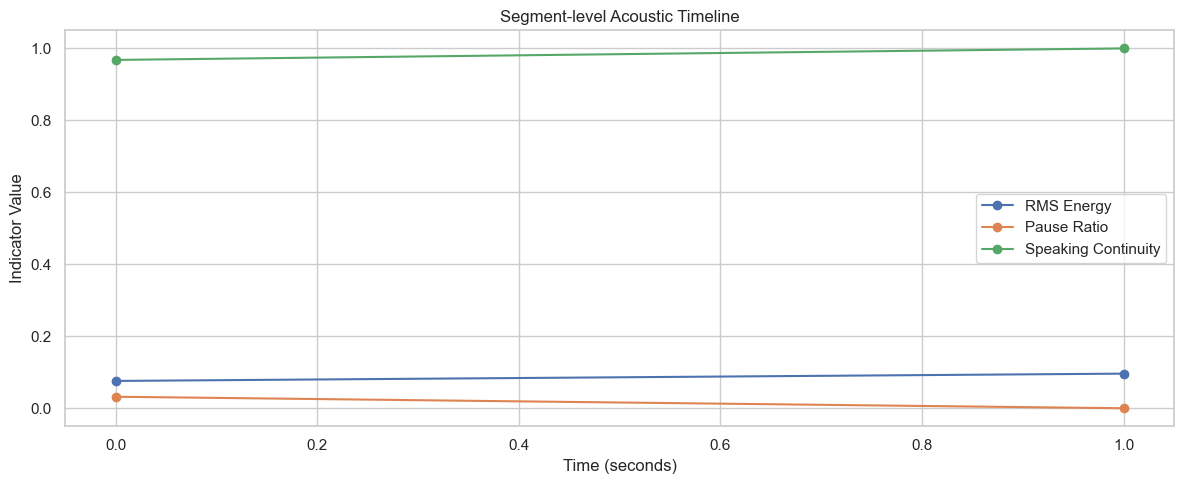

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\segment_acoustic_timeline_demo.png


In [31]:
plt.figure(figsize=(12, 5))

plt.plot(timeline_df["start_time"], timeline_df["rms_mean"], marker="o", label="RMS Energy")
plt.plot(timeline_df["start_time"], timeline_df["pause_ratio"], marker="o", label="Pause Ratio")
plt.plot(timeline_df["start_time"], timeline_df["speaking_continuity"], marker="o", label="Speaking Continuity")

plt.title("Segment-level Acoustic Timeline")
plt.xlabel("Time (seconds)")
plt.ylabel("Indicator Value")
plt.legend()
plt.tight_layout()

save_path = FIGURE_DIR / "segment_acoustic_timeline_demo.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 8. Demonstration of emotion timeline

Most samples in RAVDESS, CREMA-D and TESS are short utterances, so a single audio file may contain only a few segments.  
To demonstrate the emotion timeline more clearly, this section creates a longer demo audio by concatenating one sample from each emotion class.

This is not a real model prediction yet.  
The emotion labels in this demo are taken from the known dataset labels and are used only to demonstrate how the final timeline will work.

After the SER model is trained, these known labels can be replaced by predicted labels for each segment.

In [32]:
import soundfile as sf

def create_concatenated_demo_audio(examples_df, silence_duration=0.3):
    """
    Create a longer demo audio by concatenating one sample from each emotion.
    """
    demo_audio_parts = []
    emotion_ranges = []
    current_time = 0.0

    silence = np.zeros(int(silence_duration * TARGET_SR), dtype=np.float32)

    for _, row in examples_df.iterrows():
        y, sr = load_processed_audio(row)

        start_time = current_time
        end_time = current_time + len(y) / sr

        demo_audio_parts.append(y)
        demo_audio_parts.append(silence)

        emotion_ranges.append({
            "emotion": row["emotion"],
            "dataset": row["dataset"],
            "sample_id": row["sample_id"],
            "start_time": start_time,
            "end_time": end_time
        })

        current_time = end_time + silence_duration

    demo_audio = np.concatenate(demo_audio_parts).astype(np.float32)
    emotion_ranges = pd.DataFrame(emotion_ranges)

    return demo_audio, emotion_ranges


demo_audio, emotion_ranges = create_concatenated_demo_audio(examples)

demo_audio_path = OUTPUT_DIR / "demo_concatenated_emotions.wav"
sf.write(str(demo_audio_path), demo_audio, TARGET_SR)

print("Demo audio saved:", demo_audio_path)
print("Demo audio duration:", round(len(demo_audio) / TARGET_SR, 2), "seconds")

display(emotion_ranges)

Demo audio saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\demo_concatenated_emotions.wav
Demo audio duration: 15.42 seconds


,emotion,dataset,sample_id,start_time,end_time
0,angry,CREMA-D,s001821,0.000000,2.368000
1,disgust,CREMA-D,s006672,2.668000,5.203875
2,fear,TESS,s009001,5.503875,7.036250
3,happy,CREMA-D,s002702,7.336250,9.638562
4,neutral,CREMA-D,s007354,9.938562,12.541187
5,sad,CREMA-D,s007699,12.841188,15.116750


In [33]:
demo_segments = segment_audio(
    demo_audio,
    TARGET_SR,
    segment_duration=1.0,
    hop_duration=1.0
)

print("Number of demo segments:", len(demo_segments))

Number of demo segments: 15


In [34]:
def get_emotion_at_time(time_point, emotion_ranges):
    """
    Return the emotion label at a specific time point.
    """
    matched = emotion_ranges[
        (emotion_ranges["start_time"] <= time_point)
        & (emotion_ranges["end_time"] >= time_point)
    ]

    if len(matched) == 0:
        return "silence"

    return matched.iloc[0]["emotion"]


demo_timeline_rows = []

for i, seg in enumerate(demo_segments):
    center_time = (seg["start_time"] + seg["end_time"]) / 2
    emotion_label = get_emotion_at_time(center_time, emotion_ranges)
    seg_indicators = compute_segment_indicators(seg["audio"], TARGET_SR)

    demo_timeline_rows.append({
        "segment_id": i,
        "start_time": seg["start_time"],
        "end_time": seg["end_time"],
        "center_time": center_time,
        "timeline_emotion": emotion_label,
        **seg_indicators
    })

demo_timeline_df = pd.DataFrame(demo_timeline_rows)

display(demo_timeline_df.head(10))
display(demo_timeline_df["timeline_emotion"].value_counts())

,segment_id,start_time,end_time,center_time,timeline_emotion,pitch_mean,pitch_std,rms_mean,rms_std,zcr_mean,zcr_std,pause_ratio,speaking_continuity
0,0,0.0,1.0,0.5,angry,284.768326,37.971308,0.150014,0.079605,0.099330,0.048412,0.000,1.000
1,1,1.0,2.0,1.5,angry,281.055182,34.523612,0.134145,0.062713,0.089332,0.037305,0.000,1.000
2,2,2.0,3.0,2.5,silence,107.594377,0.839463,0.028051,0.035026,0.054998,0.046507,0.192,0.808
3,3,3.0,4.0,3.5,disgust,137.495559,13.684787,0.180863,0.090735,0.106228,0.102566,0.000,1.000
4,4,4.0,5.0,4.5,disgust,101.012849,14.059020,0.067529,0.067607,0.099888,0.086293,0.000,1.000
5,5,5.0,6.0,5.5,silence,285.046583,6.389454,0.081072,0.112199,0.122690,0.197350,0.256,0.744
6,6,6.0,7.0,6.5,fear,287.872596,28.398221,0.196440,0.039012,0.047495,0.015452,0.000,1.000
7,7,7.0,8.0,7.5,happy,168.664190,46.789911,0.106507,0.136558,0.047976,0.045611,0.288,0.712
8,8,8.0,9.0,8.5,happy,227.048154,35.821089,0.233882,0.047453,0.047960,0.014762,0.000,1.000
9,9,9.0,10.0,9.5,happy,244.724952,25.517835,0.044328,0.045840,0.030506,0.023662,0.192,0.808


timeline_emotion
happy      3
neutral    3
angry      2
disgust    2
silence    2
sad        2
fear       1
Name: count, dtype: int64

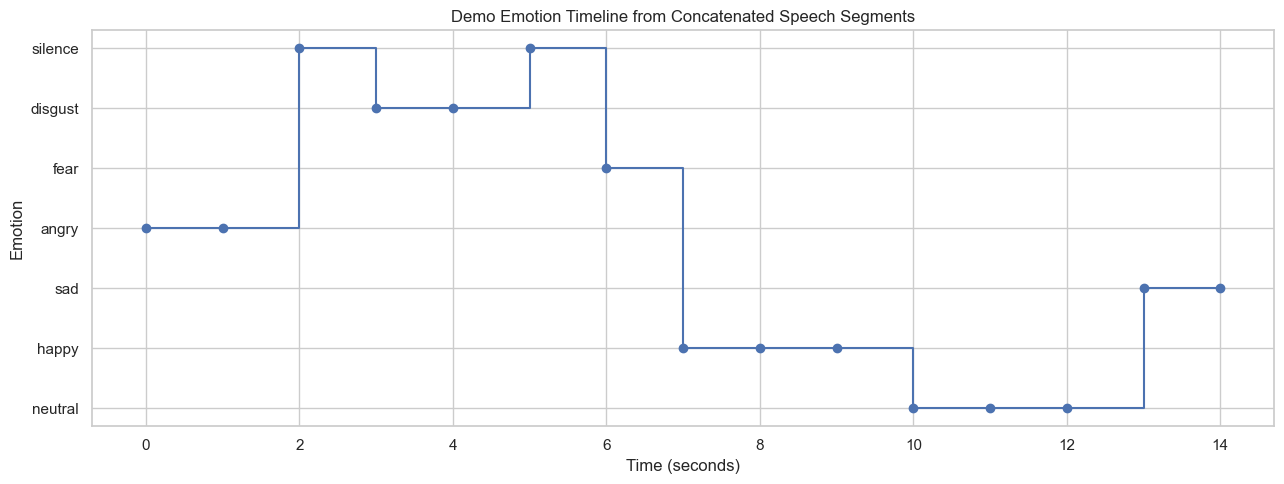

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\demo_emotion_timeline.png


In [35]:
timeline_emotions = COMMON_EMOTIONS + ["silence"]
emotion_to_id = {emotion: i for i, emotion in enumerate(timeline_emotions)}

demo_timeline_df["emotion_id"] = demo_timeline_df["timeline_emotion"].map(emotion_to_id)

plt.figure(figsize=(13, 5))

plt.step(
    demo_timeline_df["start_time"],
    demo_timeline_df["emotion_id"],
    where="post",
    marker="o"
)

plt.yticks(
    list(emotion_to_id.values()),
    list(emotion_to_id.keys())
)

plt.title("Demo Emotion Timeline from Concatenated Speech Segments")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.grid(True)
plt.tight_layout()

save_path = FIGURE_DIR / "demo_emotion_timeline.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

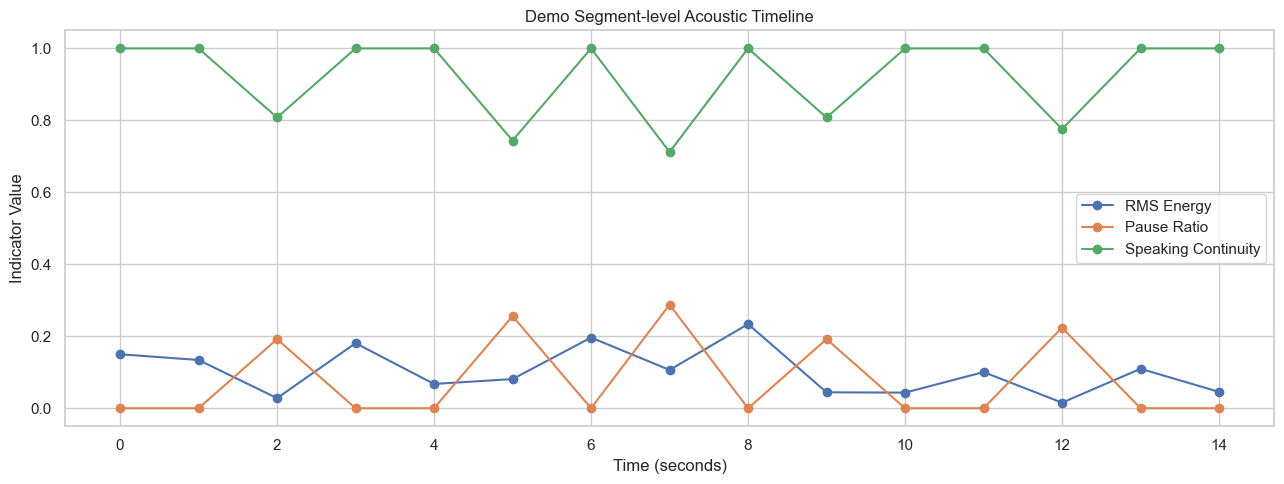

Saved: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong\demo_acoustic_timeline.png


In [36]:
plt.figure(figsize=(13, 5))

plt.plot(
    demo_timeline_df["start_time"],
    demo_timeline_df["rms_mean"],
    marker="o",
    label="RMS Energy"
)

plt.plot(
    demo_timeline_df["start_time"],
    demo_timeline_df["pause_ratio"],
    marker="o",
    label="Pause Ratio"
)

plt.plot(
    demo_timeline_df["start_time"],
    demo_timeline_df["speaking_continuity"],
    marker="o",
    label="Speaking Continuity"
)

plt.title("Demo Segment-level Acoustic Timeline")
plt.xlabel("Time (seconds)")
plt.ylabel("Indicator Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = FIGURE_DIR / "demo_acoustic_timeline.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

### Emotion timeline demonstration analysis

The demo emotion timeline shows how a longer speech recording can be divided into short time segments and represented as an emotion sequence over time.

In this demonstration, one sample from each emotion class is concatenated to create a longer audio sequence. The `silence` segments appear because short silent gaps were inserted between different emotion samples. At this stage, the emotion labels are taken from the known dataset labels, so this figure is used only to demonstrate the timeline framework, not real model prediction.

The acoustic timeline shows how **RMS energy**, **pause ratio** and **speaking continuity** change across segments. When pause ratio increases, speaking continuity decreases. This helps the system identify parts of the speech that contain more silence or less continuous speaking.

Overall, this framework shows how the final system can analyze a long speaking recording segment by segment. After the SER model is trained, the known labels in this demo can be replaced by predicted emotion labels to create a real emotion timeline for user speech.

## 9. Rule-based speaking feedback

After extracting acoustic indicators, the system can generate simple speaking feedback.

At this stage, the feedback is rule-based and uses acoustic indicators such as:

- RMS energy for voice strength.
- Pitch standard deviation for pitch stability.
- Pause ratio for hesitation or silence.
- Speaking continuity for fluency.

This feedback is not a medical diagnosis.  
It is only designed to support speaking practice by giving comments about voice energy, stability and continuity.

In [37]:
def generate_segment_feedback(row):
    """
    Generate simple feedback for one speech segment based on acoustic indicators.
    """
    comments = []

    # Voice energy
    if row["rms_mean"] < 0.05:
        comments.append("Voice energy is low; the speaker may need to speak more clearly or loudly.")
    elif row["rms_mean"] > 0.16:
        comments.append("Voice energy is strong and clear.")
    else:
        comments.append("Voice energy is moderate.")

    # Pause and continuity
    if row["pause_ratio"] > 0.20:
        comments.append("This segment contains noticeable silence or hesitation.")
    elif row["speaking_continuity"] > 0.90:
        comments.append("Speech continuity is good.")
    else:
        comments.append("Speech continuity is acceptable but could be smoother.")

    # Pitch stability
    if row["pitch_std"] > 70:
        comments.append("Pitch variation is high, which may indicate expressive or unstable speaking.")
    elif row["pitch_std"] < 20:
        comments.append("Pitch is relatively stable.")
    else:
        comments.append("Pitch variation is moderate.")

    return " ".join(comments)

In [38]:
demo_timeline_df["segment_feedback"] = demo_timeline_df.apply(
    generate_segment_feedback,
    axis=1
)

display(demo_timeline_df[[
    "segment_id",
    "start_time",
    "end_time",
    "timeline_emotion",
    "rms_mean",
    "pitch_std",
    "pause_ratio",
    "speaking_continuity",
    "segment_feedback"
]])

,segment_id,start_time,end_time,timeline_emotion,rms_mean,pitch_std,pause_ratio,speaking_continuity,segment_feedback
0,0,0.0,1.0,angry,0.150014,37.971308,0.000,1.000,Voice energy is moderate. Speech continuity is...
1,1,1.0,2.0,angry,0.134145,34.523612,0.000,1.000,Voice energy is moderate. Speech continuity is...
2,2,2.0,3.0,silence,0.028051,0.839463,0.192,0.808,Voice energy is low; the speaker may need to s...
3,3,3.0,4.0,disgust,0.180863,13.684787,0.000,1.000,Voice energy is strong and clear. Speech conti...
4,4,4.0,5.0,disgust,0.067529,14.059020,0.000,1.000,Voice energy is moderate. Speech continuity is...
5,5,5.0,6.0,silence,0.081072,6.389454,0.256,0.744,Voice energy is moderate. This segment contain...
6,6,6.0,7.0,fear,0.196440,28.398221,0.000,1.000,Voice energy is strong and clear. Speech conti...
7,7,7.0,8.0,happy,0.106507,46.789911,0.288,0.712,Voice energy is moderate. This segment contain...
8,8,8.0,9.0,happy,0.233882,35.821089,0.000,1.000,Voice energy is strong and clear. Speech conti...
9,9,9.0,10.0,happy,0.044328,25.517835,0.192,0.808,Voice energy is low; the speaker may need to s...


In [39]:
def generate_overall_feedback(timeline_df):
    """
    Generate overall speaking feedback from segment-level indicators.
    """
    avg_rms = timeline_df["rms_mean"].mean()
    avg_pause = timeline_df["pause_ratio"].mean()
    avg_continuity = timeline_df["speaking_continuity"].mean()
    avg_pitch_std = timeline_df["pitch_std"].mean()

    feedback = []

    feedback.append("Overall speaking feedback:")

    if avg_rms < 0.05:
        feedback.append("- The overall voice energy is quite low. The speaker should try to speak more clearly and confidently.")
    elif avg_rms > 0.16:
        feedback.append("- The overall voice energy is strong.")
    else:
        feedback.append("- The overall voice energy is moderate and acceptable.")

    if avg_pause > 0.20:
        feedback.append("- The speech contains several silent or hesitant regions. Reducing long pauses may improve fluency.")
    else:
        feedback.append("- The pause ratio is low, which suggests good speaking continuity.")

    if avg_continuity > 0.90:
        feedback.append("- Speaking continuity is good across most segments.")
    else:
        feedback.append("- Speaking continuity could be improved in some segments.")

    if avg_pitch_std > 70:
        feedback.append("- Pitch variation is high. This can make the speech expressive, but too much variation may sound unstable.")
    elif avg_pitch_std < 20:
        feedback.append("- Pitch is stable, but the speech may sound less expressive.")
    else:
        feedback.append("- Pitch variation is moderate.")

    return "\n".join(feedback)


overall_feedback = generate_overall_feedback(demo_timeline_df)
print(overall_feedback)

Overall speaking feedback:
- The overall voice energy is moderate and acceptable.
- The pause ratio is low, which suggests good speaking continuity.
- Speaking continuity is good across most segments.
- Pitch variation is moderate.


In [40]:
feedback_csv_path = OUTPUT_DIR / "demo_timeline_feedback_minhcuong.csv"
feedback_txt_path = OUTPUT_DIR / "demo_overall_feedback_minhcuong.txt"

demo_timeline_df.to_csv(feedback_csv_path, index=False)

with open(feedback_txt_path, "w", encoding="utf-8") as f:
    f.write(overall_feedback)

print("Saved CSV:", feedback_csv_path)
print("Saved TXT:", feedback_txt_path)

Saved CSV: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\demo_timeline_feedback_minhcuong.csv
Saved TXT: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\demo_overall_feedback_minhcuong.txt


### Speaking feedback analysis

The rule-based feedback module converts acoustic indicators into simple comments for speaking practice.

For each segment, the system checks voice energy, pause ratio, speaking continuity and pitch variation.  
Based on these values, it can generate comments such as low voice energy, good continuity, noticeable silence or high pitch variation.

The overall feedback summarizes the average speaking behavior across all segments.  
This is useful for a speaking practice system because users can receive both segment-level feedback and general feedback for the whole recording.

At this stage, the feedback rules are simple and interpretable.  
In the final version, these rules can be improved by combining acoustic indicators with the predicted emotion timeline from the trained SER model.

## 10. Generated artifacts

This notebook generated several figures and output files for EDA, feature visualization, acoustic indicator analysis and timeline demonstration.

### Figures

The generated figures include:

- Dataset distribution by source.
- Emotion label distribution.
- Audio duration distribution.
- Waveform, spectrogram, MFCC and Log-Mel visualization for six emotion classes.
- Acoustic indicator boxplots.
- Segment-level acoustic timeline.
- Demo emotion timeline.
- Demo acoustic timeline.

These figures can be used directly in the midterm report and presentation slides.

### Output files

The notebook also exported:

- `acoustic_indicators_minhcuong.csv`: acoustic indicators computed from selected samples.
- `demo_concatenated_emotions.wav`: demo audio created by concatenating samples from different emotion classes.
- `demo_timeline_feedback_minhcuong.csv`: segment-level feedback table.
- `demo_overall_feedback_minhcuong.txt`: overall speaking feedback generated from acoustic indicators.

These artifacts demonstrate how the proposed speaking feedback system can analyze emotion-related speech features and generate interpretable feedback.

In [41]:
print("Figures saved in:", FIGURE_DIR)
for p in sorted(FIGURE_DIR.glob("*.png")):
    print("-", p.name)

print("\nMain artifacts saved in:", OUTPUT_DIR)
for p in [
    OUTPUT_DIR / "acoustic_indicators_minhcuong.csv",
    OUTPUT_DIR / "demo_concatenated_emotions.wav",
    OUTPUT_DIR / "demo_timeline_feedback_minhcuong.csv",
    OUTPUT_DIR / "demo_overall_feedback_minhcuong.txt"
]:
    print("-", p.name, "| exists:", p.exists())

Figures saved in: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed\figures_minhcuong
- acoustic_indicators_boxplot.png
- demo_acoustic_timeline.png
- demo_emotion_timeline.png
- duration_distribution.png
- features_angry_s001821.png
- features_disgust_s006672.png
- features_fear_s009001.png
- features_happy_s002702.png
- features_neutral_s007354.png
- features_sad_s007699.png
- samples_by_dataset.png
- samples_by_emotion.png
- segment_acoustic_timeline_demo.png

Main artifacts saved in: D:\UTE\Speech Programming\Speech Project\EDA\ser_processed
- acoustic_indicators_minhcuong.csv | exists: True
- demo_concatenated_emotions.wav | exists: True
- demo_timeline_feedback_minhcuong.csv | exists: True
- demo_overall_feedback_minhcuong.txt | exists: True


## 11. Rubric checklist

This notebook supports the midterm rubric, especially the Speech Data and Feature Extraction section.

### Rubric 2.1 — Dataset overview

The notebook summarizes the processed dataset from RAVDESS, CREMA-D and TESS.  
It presents the number of samples, dataset sources, emotion labels and general data structure.

### Rubric 2.2 — Dataset structure

The notebook analyzes metadata fields such as dataset name, emotion label, speaker ID, duration and split.  
It also shows the distribution of samples by dataset and emotion class.

### Rubric 2.3 — Data preparation

This notebook continues from the previous preprocessing stage, which included resampling to 16 kHz, label mapping, audio normalization and speaker-independent splitting.  
The notebook uses processed 16 kHz audio files for visualization and acoustic analysis.

### Rubric 2.4 — Speech features

The notebook explains and visualizes important speech features, including waveform, spectrogram, MFCC, Log-Mel spectrogram, RMS energy, pitch/F0, ZCR, pause ratio and speaking continuity.

### Rubric 2.5 — Feature illustration and analysis

The notebook provides charts and figures for dataset distribution, feature visualization, acoustic indicators and segment-level timeline analysis.  
These figures help explain how speech features can support emotion recognition and speaking feedback.

### Initial system demonstration

The notebook also builds an initial timeline and feedback framework.  
Although the final SER model prediction is not included yet, the current implementation demonstrates how long speech can be segmented and analyzed over time.

## 12. Conclusion

This notebook extends the processed speech emotion dataset into a deeper analysis stage.

First, the dataset distribution was analyzed to understand sample imbalance, emotion distribution and duration differences across datasets.  
Then, several speech feature representations were visualized, including waveform, spectrogram, MFCC and Log-Mel spectrogram. These features are important because they represent speech signals in both time and frequency domains.

Next, acoustic speaking indicators were extracted and analyzed. RMS energy, pitch/F0, ZCR, pause ratio and speaking continuity provide useful information for speaking feedback. These indicators can describe voice strength, pitch stability, hesitation and fluency.

Finally, the notebook built a demonstration framework for segment-level analysis. A longer demo audio was created by concatenating short emotion samples, then the audio was divided into segments to create an emotion timeline and acoustic timeline. A simple rule-based feedback module was also implemented to generate speaking feedback from acoustic indicators.

Overall, this notebook shows that the project is feasible for the midterm stage. It provides the foundation for the next steps: integrating a trained Speech Emotion Recognition model, replacing demo labels with predicted labels and connecting the timeline analysis to a dashboard application.